In [86]:
import numpy as np 
import matplotlib.pyplot as plt

In [87]:
log_prob_matrix_d = np.load('log_probs.npy')

In [88]:
log_prob_matrix_d.shape

(100, 5000)

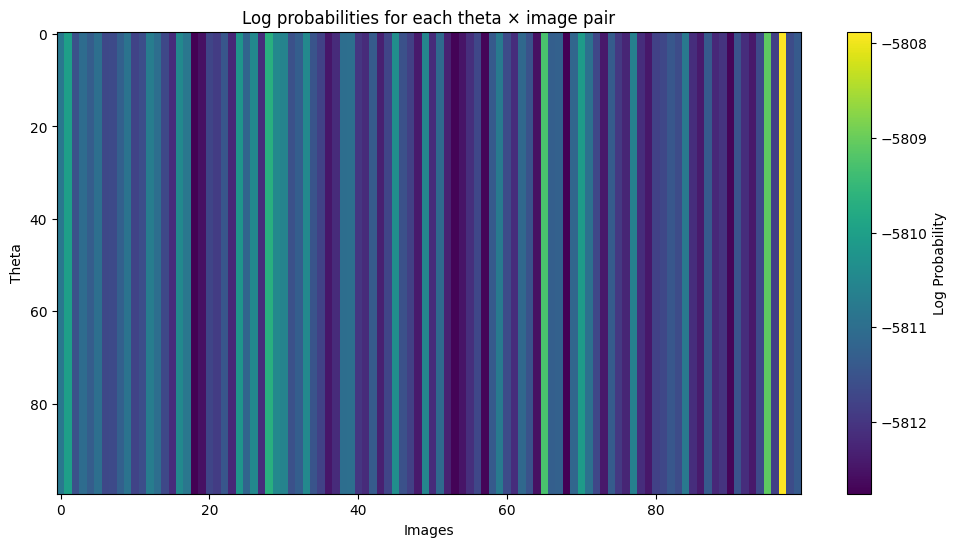

In [89]:
plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d[:100,:100], aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image pair')
plt.show()


In [90]:
# GENERAL PARAMETERS
# number of models
nframes=100#121
# number of maps
nmaps=5000 #3255453

In [91]:
# Objective function
def F(X):
    s = P.T @ X  # shape (M,)
    return -np.sum(np.log(s))

# Gradient
def grad_F(X):
    s = P.T @ X  # shape (M,)
    return -P @ (1.0 / s)  # shape (N,)

# minimizer
class ProjectedGradientDescentSimplex:
    def __init__(self, func, grad, n_vars, max_iters=10000, tol=1e-9):
        """
        func: callable f(x) -> float
        grad: callable grad_f(x) -> np.ndarray
        n_vars: number of variables
        max_iters: maximum iterations
        tol: tolerance for convergence
        """
        self.func = func
        self.grad = grad
        self.n_vars = n_vars
        self.max_iters = max_iters
        self.tol = tol
        self.history = []  # store f(x) values

    def project_to_simplex(self, v):
        """ Project v onto the unit simplex {x | sum(x)=1, x>=0} """
        n = len(v)
        u = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho = np.nonzero(u * np.arange(1, n+1) > (cssv - 1))[0][-1]
        theta = (cssv[rho] - 1.0) / (rho + 1)
        return np.maximum(v - theta, 0.0)

    def minimize(self, x0=None):
        # Initialize
        if x0 is None:
            x = np.random.rand(self.n_vars)
        else:
            x = np.array(x0, dtype=np.float64)
        x = self.project_to_simplex(x)

        self.history = [self.func(x)]

        for i in range(self.max_iters):
            grad = self.grad(x)
            f_val = self.func(x)

            # Backtracking line search
            step = 1.0
            while True:
                x_new = self.project_to_simplex(x - step * grad)
                if self.func(x_new) <= f_val - 1e-4 * step * np.dot(grad, x - x_new):
                    break
                step *= 0.5
                if step < 1e-12:
                    break

            self.history.append(self.func(x_new))

            # Convergence check
            if np.linalg.norm(x_new - x) < self.tol:
                print(f"Converged in {i} iterations")
                return x_new

            x = x_new

        print("Reached maximum iterations")
        return x

    def plot_convergence(self):
        plt.figure(figsize=(6,4))
        plt.plot(self.history, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("f(x)")
        plt.title("Convergence of Projected Gradient Descent")
        plt.grid(True)
        plt.show()

In [92]:
# create probability array
P = np.array(log_prob_matrix_d, dtype=np.float64)
# get maximum value
m = np.max(P)
# get likelihood probability matrix Nmodels*Nimages
P = np.exp(P-m)
# convert Nan or weird values into zero
#P = np.nan_to_num(P, nan=0.0, posinf=0.0, neginf=0.0)
# Make initial random weight vector the size of the number of nframes-1
w_i = np.random.random(nframes-1)
# sort values and insert 0 and 1
w_t = np.append(np.insert(np.sort(w_i), 0, 0.0), 1.0)
# Prepare weight array
X0 = np.zeros(nframes, dtype=np.float64)
# Loop through frames & subtract value n from value n+1
for b in range(nframes):
    X0[b] = w_t[b+1] - w_t[b]

In [93]:
# run minimization
pgd = ProjectedGradientDescentSimplex(func=F, grad=grad_F, n_vars=nframes)
x_opt = pgd.minimize(X0)

print("Optimal x:", x_opt)
print("Sum of x:", np.sum(x_opt))
print("Minimum f(x):", F(x_opt))




Converged in 0 iterations
Optimal x: [7.63596805e-03 1.24700069e-02 9.04332543e-04 3.58471113e-03
 1.94639766e-02 1.08462327e-02 2.05328060e-03 3.14481945e-03
 1.38801713e-02 2.51865592e-02 4.29401981e-03 2.51171731e-02
 2.53583967e-02 2.07430975e-03 3.25813159e-03 5.10268863e-03
 1.05370288e-02 3.91218649e-03 5.34426722e-03 1.66938796e-02
 1.26601897e-03 1.17981077e-02 8.08078908e-04 3.24956696e-04
 3.30543439e-02 1.22461728e-02 4.77649012e-04 2.54050495e-02
 9.99062298e-03 3.07490731e-03 1.80496507e-02 3.29467865e-04
 3.08097807e-02 1.04912430e-02 3.21836670e-02 4.07510563e-04
 4.03041829e-02 2.02303872e-02 6.28886112e-03 2.45204366e-03
 1.61987798e-03 1.29734341e-02 3.30395765e-03 8.02219702e-03
 3.42184064e-03 4.22639118e-03 8.97400023e-03 7.80204439e-04
 7.03145662e-03 7.82370691e-03 3.73154080e-02 1.22854683e-04
 1.70414684e-02 6.32593794e-03 1.42579445e-02 1.47169793e-02
 1.79937569e-02 6.09138752e-04 1.28456563e-02 4.83903226e-03
 4.16119228e-03 9.22770896e-03 8.45275930e-03 2.

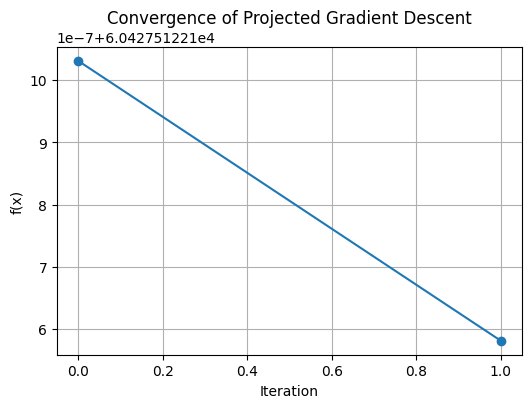

In [94]:
# Plot convergence
pgd.plot_convergence()

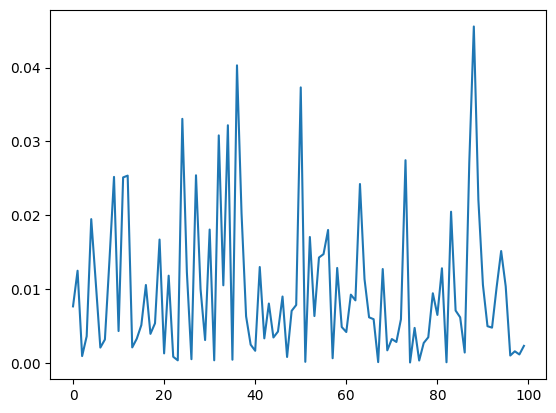

In [95]:
plt.plot(x_opt)

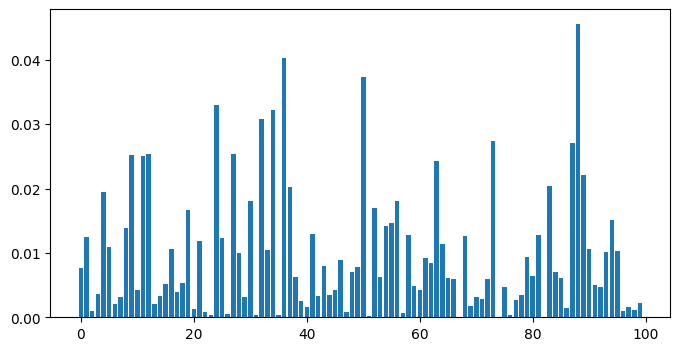

In [96]:
plt.figure(figsize=(8,4))
plt.bar(range(len(x_opt)), x_opt)
plt.show()


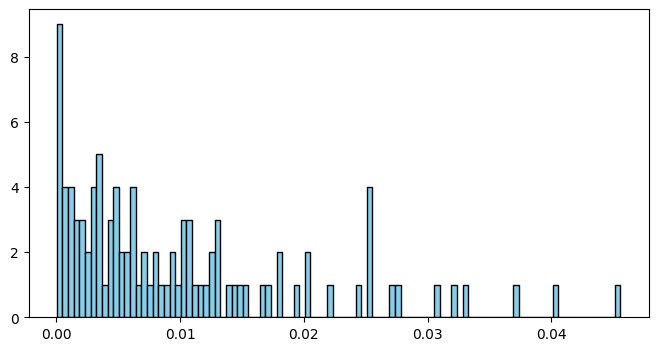

In [97]:
plt.figure(figsize=(8,4))
plt.hist(x_opt, bins=100, color='skyblue', edgecolor='black')
plt.show()